# 07 — Tree Model Comparison

比較 naive、Ridge 與 Histogram Gradient Boosting（HGB），所有模型使用相同 top-100 站點、時間切分與 hourly transfer-demand target。

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
comparison = pd.read_csv(ROOT / 'results/model_comparison_metrics.csv')
rolling = pd.read_csv(ROOT / 'results/tree_rolling_origin_metrics.csv')
importance = pd.read_csv(ROOT / 'results/tree_permutation_importance.csv')
station_errors = pd.read_csv(ROOT / 'results/tree_station_errors.csv')
hour_errors = pd.read_csv(ROOT / 'results/tree_hour_errors.csv')
comparison.query("split == 'test'").sort_values('mae')

,model,split,alpha,rows,mae,rmse,r2,candidate
11,hist_gradient_boosting_weather,test,NaN,74282,1.574743,2.548743,0.794207,deeper
9,hist_gradient_boosting,test,NaN,74282,1.601385,2.567141,0.791225,deeper
7,ridge_time_history_weather,test,0.1,74282,1.793286,2.889303,0.735536,NaN
5,ridge_time_history,test,100.0,74282,1.809618,2.911339,0.731487,NaN
3,seasonal_168h,test,NaN,74282,2.176274,3.700872,0.566102,NaN
2,persistence_1h,test,NaN,74282,2.441305,4.129208,0.459852,NaN


## Holdout 模型比較
12 月測試集只在模型與參數選定後評估。

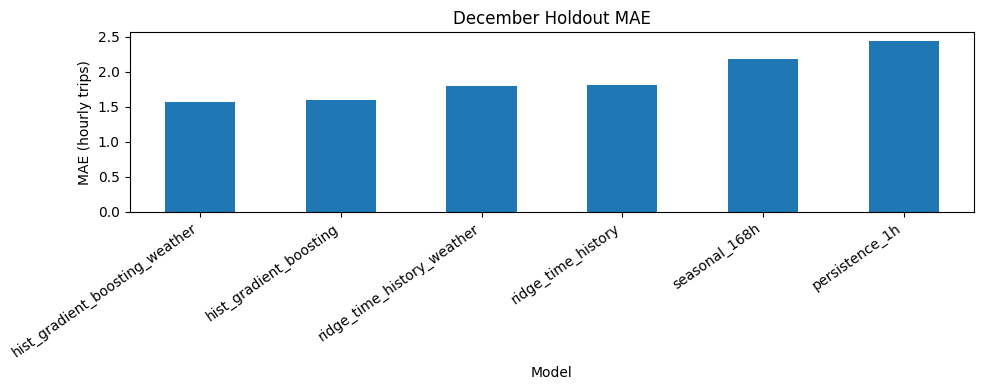

MAE improvement vs weather Ridge (%)        12.186733
MAE improvement vs seasonal baseline (%)    27.640432
dtype: float64

In [2]:
test = comparison.query("split == 'test'").sort_values('mae')
ax = test.plot.bar(x='model', y='mae', figsize=(10, 4), legend=False)
ax.set(title='December Holdout MAE', xlabel='Model', ylabel='MAE (hourly trips)')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()
best = test.set_index('model').loc['hist_gradient_boosting_weather']
ridge = test.set_index('model').loc['ridge_time_history_weather']
seasonal = test.set_index('model').loc['seasonal_168h']
pd.Series({
    'MAE improvement vs weather Ridge (%)': (ridge.mae - best.mae) / ridge.mae * 100,
    'MAE improvement vs seasonal baseline (%)': (seasonal.mae - best.mae) / seasonal.mae * 100,
})

## Rolling-origin 穩定性
每個 fold 都只使用評估期間以前的資料，訓練視窗逐步擴張。

,fold,train_end,validation_start,validation_end,train_rows,validation_rows,mae,rmse,r2
0,fold_1,2023-09-30T23:00:00+08:00,2023-10-01T00:00:00+08:00,2023-10-20T23:00:00+08:00,638098,48000,1.635973,2.716172,0.762450
1,fold_2,2023-10-20T23:00:00+08:00,2023-10-21T00:00:00+08:00,2023-11-10T23:00:00+08:00,686098,50400,1.592232,2.572919,0.818161
2,fold_3,2023-11-10T23:00:00+08:00,2023-11-11T00:00:00+08:00,2023-11-30T23:00:00+08:00,736498,48000,1.605758,2.607629,0.797445


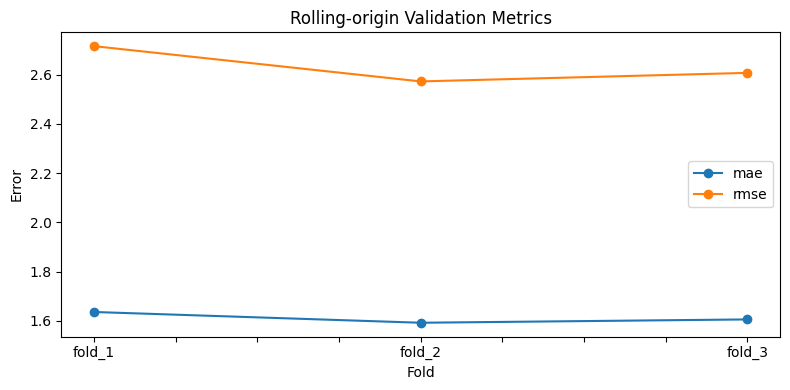

,mae,rmse,r2
mean,1.611321,2.632240,0.792685
min,1.592232,2.572919,0.762450
max,1.635973,2.716172,0.818161


In [3]:
display(rolling)
ax = rolling.plot(x='fold', y=['mae', 'rmse'], marker='o', figsize=(8, 4))
ax.set(title='Rolling-origin Validation Metrics', xlabel='Fold', ylabel='Error')
plt.tight_layout()
plt.show()
rolling[['mae', 'rmse', 'r2']].agg(['mean', 'min', 'max'])

## Permutation importance

重要度是在固定 10,000 筆測試樣本中打亂單一欄位後的 MAE 增量，反映模型依賴程度，不代表因果關係。

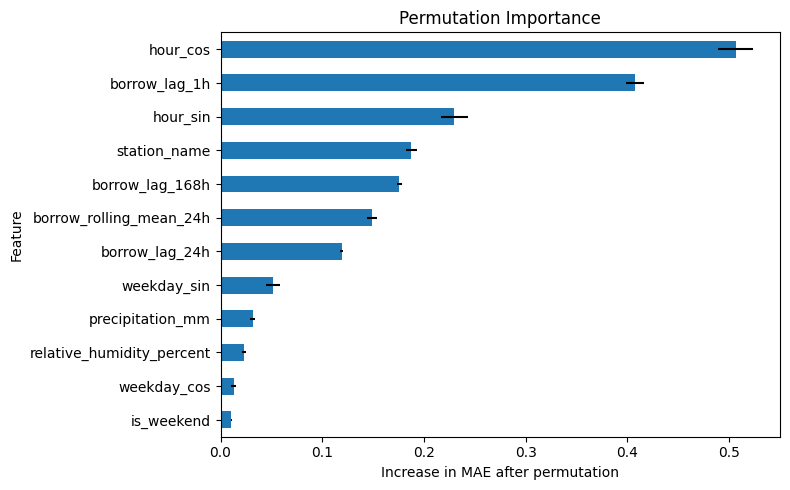

,feature,mae_increase_mean,mae_increase_std
0,hour_cos,0.506711,0.017292
1,borrow_lag_1h,0.407544,0.008903
2,hour_sin,0.230023,0.013227
3,station_name,0.187598,0.005457
4,borrow_lag_168h,0.175668,0.002437
5,borrow_rolling_mean_24h,0.148908,0.004496
6,borrow_lag_24h,0.119259,0.001357
7,weekday_sin,0.051484,0.006960
8,precipitation_mm,0.031926,0.002460
9,relative_humidity_percent,0.022959,0.001934


In [4]:
top_importance = importance.head(12).sort_values('mae_increase_mean')
ax = top_importance.plot.barh(x='feature', y='mae_increase_mean', xerr='mae_increase_std', figsize=(8, 5), legend=False)
ax.set(title='Permutation Importance', xlabel='Increase in MAE after permutation', ylabel='Feature')
plt.tight_layout()
plt.show()
importance.head(12)

## 尖峰與站點誤差
非線性模型降低整體誤差，但 17–18 時與最高需求站仍最難預測。

/var/folders/ks/w1ns79m97v73dhf2r3q6_zm00000gn/T/ipykernel_40549/712180990.py:7: UserWarning: Glyph 25463 (\N{CJK UNIFIED IDEOGRAPH-6377}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ks/w1ns79m97v73dhf2r3q6_zm00000gn/T/ipykernel_40549/712180990.py:7: UserWarning: Glyph 36939 (\N{CJK UNIFIED IDEOGRAPH-904B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ks/w1ns79m97v73dhf2r3q6_zm00000gn/T/ipykernel_40549/712180990.py:7: UserWarning: Glyph 33437 (\N{CJK UNIFIED IDEOGRAPH-829D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ks/w1ns79m97v73dhf2r3q6_zm00000gn/T/ipykernel_40549/712180990.py:7: UserWarning: Glyph 23665 (\N{CJK UNIFIED IDEOGRAPH-5C71}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ks/w1ns79m97v73dhf2r3q6_zm00000gn/T/ipykernel_40549/712180990.py:7: UserWarning: Glyph 31449 (\N{CJK UNIFIED IDEOGRAPH-7AD9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ks/w1ns79m97v73dh

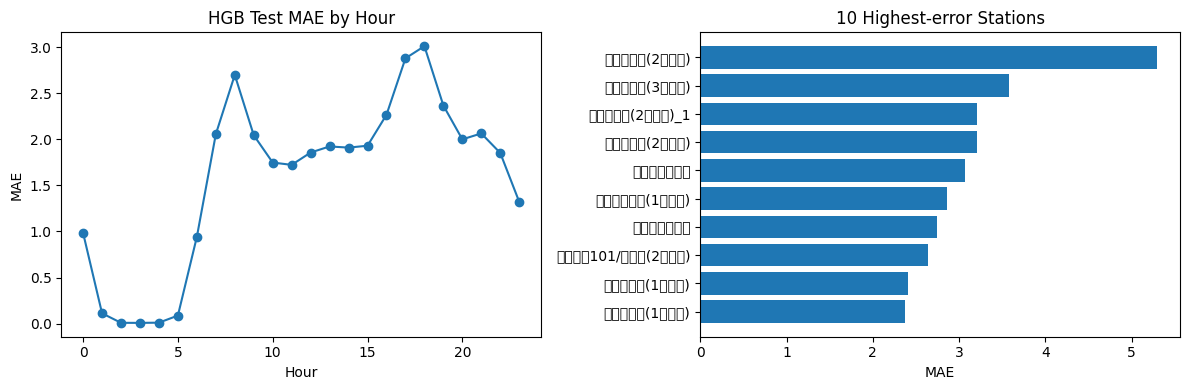

,station_name,rows,average_actual,average_prediction,mae
0,捷運公館站(2號出口),744,20.987903,20.223650,5.294065
1,捷運公館站(3號出口),744,11.005376,10.700321,3.571766
2,捷運芝山站(2號出口)_1,744,11.327957,11.514196,3.205612
3,捷運劍潭站(2號出口),742,9.749326,9.890178,3.205352
4,捷運科技大樓站,744,11.994624,11.680570,3.063462
5,捷運龍山寺站(1號出口),744,9.754032,9.690116,2.856147
6,捷運中山國中站,744,9.239247,9.265573,2.744084
7,捷運臺北101/世貿站(2號出口),737,7.436906,7.273274,2.633403
8,捷運圓山站(1號出口),743,7.664872,7.654115,2.407550
9,捷運芝山站(1號出口),744,6.782258,7.013170,2.372816


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hour_errors['hour'], hour_errors['mae'], marker='o')
axes[0].set(title='HGB Test MAE by Hour', xlabel='Hour', ylabel='MAE')
worst = station_errors.head(10).sort_values('mae')
axes[1].barh(worst['station_name'], worst['mae'])
axes[1].set(title='10 Highest-error Stations', xlabel='MAE')
plt.tight_layout()
plt.show()
station_errors.head(10)

## 結論

HGB 在 holdout 與三個 rolling folds 都優於 Stage 6 Ridge。天氣仍有小幅增益，但 precipitation 與 humidity 比單一 is_raining flag 更有用。下一步應建立一致的推論介面與模型卡，再考慮更大型模型。